# COOLANT Stage 1 — Visualize Trained Model

Loads weights from `03_coolant_training.ipynb` checkpoints and produces:

-   Training curves (loss, accuracy, macro-F1)
-   Test confusion matrix
-   Per-class metrics bar chart
-   LR schedule curves
-   Stage 1 output distribution (fake_prob, attention weights)

**Input:** `training/checkpoints_coolant/<run>/best_model.pth` + `artifacts/`

Set `CHECKPOINT_DIR` below to point at the run directory.


In [10]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
import os, sys
from pathlib import Path

try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

PROJECT_ROOT = (
    _nb_path.parents[1] if _nb_path.parent.name == "pipeline" else _nb_path.parents[1]
)
sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
import platform as _platform_mod

_plat = (
    "mac"
    if sys.platform == "darwin"
    else ("windows" if sys.platform == "win32" else "vastai")
)
_env_file = PROJECT_ROOT / f".env.{_plat}"
if not _env_file.exists():
    _env_file = PROJECT_ROOT / ".env"
load_dotenv(_env_file, override=True)

from src.utils.env_utils import get_data_root

DATA_ROOT = get_data_root()

CHECKPOINT_ROOT = DATA_ROOT / "training" / "checkpoints_coolant"


# ── Auto-select the latest completed run (has best_model.pth) ──────────────
def find_latest_run(root):
    candidates = sorted(
        [d for d in root.iterdir() if d.is_dir() and (d / "best_model.pth").exists()],
        key=lambda d: d.name,
    )
    if not candidates:
        raise FileNotFoundError(f"No completed run found under {root}")
    return candidates[-1]


CHECKPOINT_DIR = find_latest_run(CHECKPOINT_ROOT)
BEST_MODEL_PATH = CHECKPOINT_DIR / "best_model.pth"
ARTIFACT_DIR = CHECKPOINT_DIR / "artifacts"

print(f"Run dir      : {CHECKPOINT_DIR}")
print(f"Best model   : {BEST_MODEL_PATH}")
print(f"Artifacts    : {ARTIFACT_DIR}")

Run dir      : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928
Best model   : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/best_model.pth
Artifacts    : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/artifacts


In [11]:
# ── IMPORTS ────────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.models.resnet_coolant import ResNetCOOLANT
from src.preprocessing.coolant.pair_dataset import create_coolant_dataloaders
from src.preprocessing.coolant.training_utils import make_detection_batch

sns.set_theme(style="whitegrid", palette="muted")
print("Imports OK")

Imports OK


In [12]:
# ── LOAD ARTIFACTS ─────────────────────────────────────────────────────────
with open(ARTIFACT_DIR / "training_history.json") as f:
    history = json.load(f)

with open(ARTIFACT_DIR / "test_report.json") as f:
    test_report = json.load(f)

history_df = pd.DataFrame(history)
print(f"Training history: {len(history)} epochs")
print(
    f"Best epoch: {test_report['best_epoch']}  val_acc={test_report['best_val_accuracy']}"
)
print(
    f"Test accuracy: {test_report['test_accuracy']}  test_macro_f1: {test_report['test_macro_f1']}"
)
history_df.head()

Training history: 26 epochs
Best epoch: 18  val_acc=0.8695
Test accuracy: 0.8507  test_macro_f1: 0.8474


,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,lr_similarity,lr_clip,lr_detection,skipped_batches,checkpoint_path
0,0,2.2329,0.4938,0.4938,0.6968,0.5162,0.5124,0.000100,0.000100,0.000100,0,None
1,1,2.0317,0.5161,0.5159,0.6919,0.5441,0.5111,0.000100,0.000100,0.000100,0,None
2,2,1.9626,0.5338,0.5337,0.6737,0.5696,0.5622,0.000099,0.000099,0.000099,0,None
3,3,1.9074,0.5947,0.5946,0.6406,0.6549,0.6480,0.000097,0.000097,0.000097,0,None
4,4,1.8283,0.6815,0.6814,0.5701,0.7401,0.7336,0.000095,0.000095,0.000095,0,/Users/haila/Library/CloudStorage/GoogleDrive-...


## 1. Training Curves — Loss, Accuracy, Macro-F1


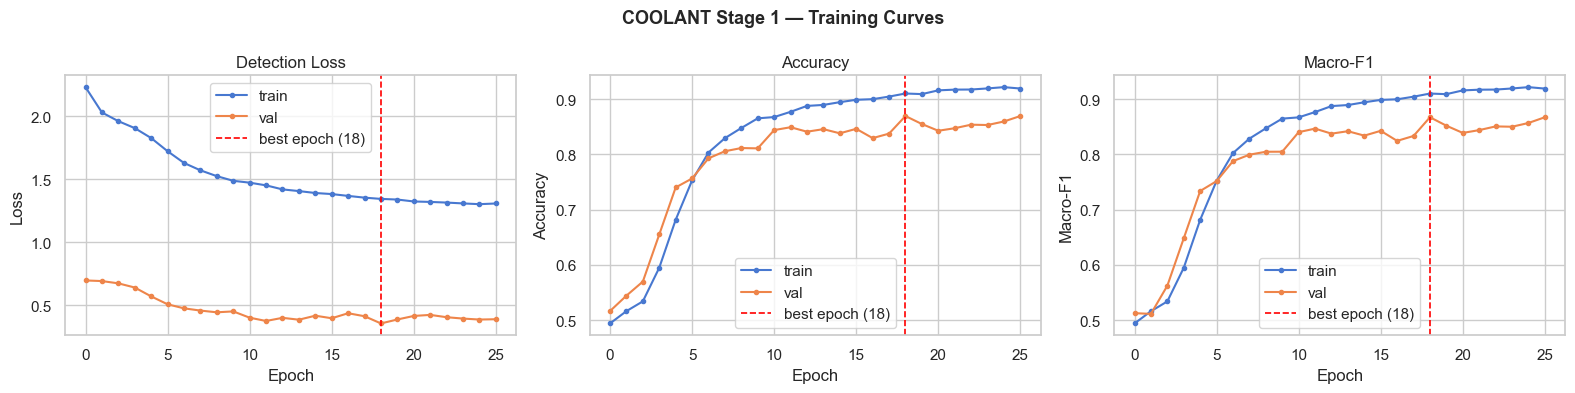

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = history_df["epoch"]
best_ep = test_report["best_epoch"]


def _vline(ax):
    ax.axvline(
        best_ep,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"best epoch ({best_ep})",
    )


# Loss
axes[0].plot(epochs, history_df["train_loss"], label="train", marker="o", markersize=3)
axes[0].plot(epochs, history_df["val_loss"], label="val", marker="o", markersize=3)
_vline(axes[0])
axes[0].set_title("Detection Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(
    epochs, history_df["train_accuracy"], label="train", marker="o", markersize=3
)
axes[1].plot(epochs, history_df["val_accuracy"], label="val", marker="o", markersize=3)
_vline(axes[1])
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# Macro-F1
axes[2].plot(
    epochs, history_df["train_macro_f1"], label="train", marker="o", markersize=3
)
axes[2].plot(epochs, history_df["val_macro_f1"], label="val", marker="o", markersize=3)
_vline(axes[2])
axes[2].set_title("Macro-F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro-F1")
axes[2].legend()

plt.suptitle("COOLANT Stage 1 — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Learning Rate Schedule


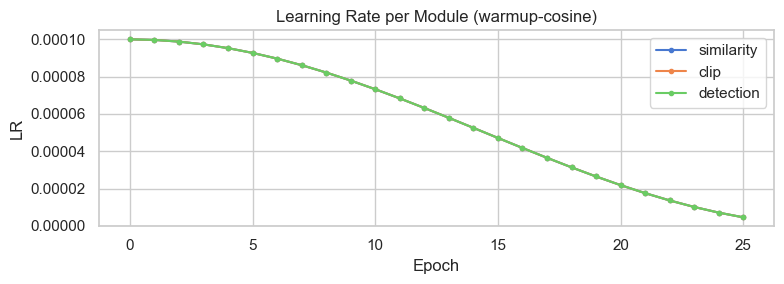

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
for col, label in [
    ("lr_similarity", "similarity"),
    ("lr_clip", "clip"),
    ("lr_detection", "detection"),
]:
    if col in history_df.columns:
        ax.plot(epochs, history_df[col], label=label, marker="o", markersize=3)

ax.set_title("Learning Rate per Module (warmup-cosine)")
ax.set_xlabel("Epoch")
ax.set_ylabel("LR")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Test Confusion Matrix


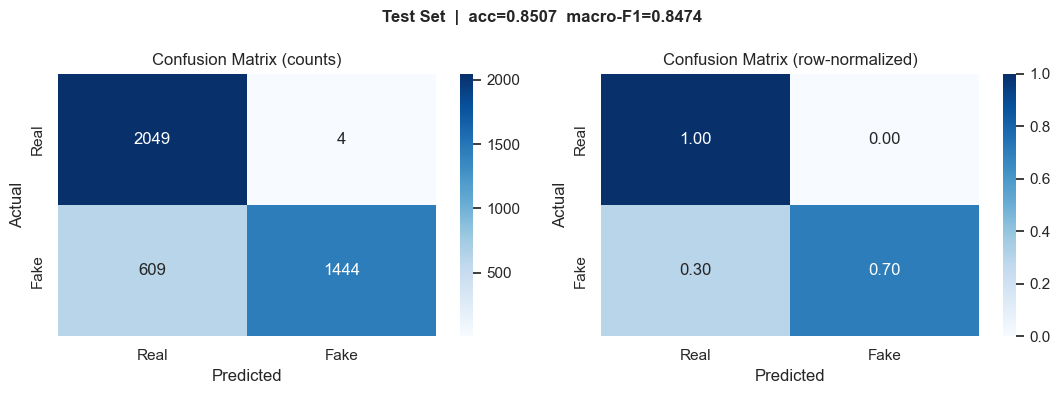

In [15]:
cm = np.array(test_report["confusion_matrix"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"],
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"],
    ax=axes[1],
    vmin=0,
    vmax=1,
)
axes[1].set_title("Confusion Matrix (row-normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle(
    f"Test Set  |  acc={test_report['test_accuracy']:.4f}  macro-F1={test_report['test_macro_f1']:.4f}",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 4. Per-Class Precision / Recall Bar Chart


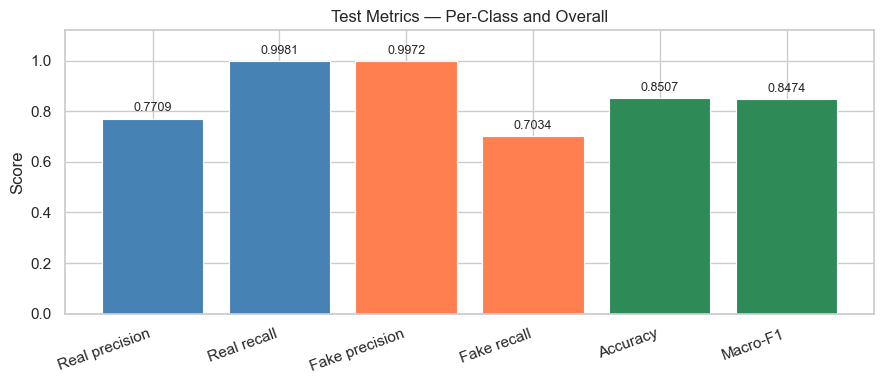

In [16]:
metrics_bar = {
    "Real precision": test_report["test_real_precision"],
    "Real recall": test_report["test_real_recall"],
    "Fake precision": test_report["test_fake_precision"],
    "Fake recall": test_report["test_fake_recall"],
    "Accuracy": test_report["test_accuracy"],
    "Macro-F1": test_report["test_macro_f1"],
}

colors = ["steelblue", "steelblue", "coral", "coral", "seagreen", "seagreen"]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    metrics_bar.keys(),
    metrics_bar.values(),
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Test Metrics — Per-Class and Overall")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. Load Best Checkpoint and Run Inference on Test Split


In [17]:
# ── Load checkpoint ────────────────────────────────────────────────────────
ckpt = torch.load(BEST_MODEL_PATH, map_location="cpu")
config = ckpt["config"]

DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)
print(f"Device: {DEVICE}")

model = ResNetCOOLANT.from_config(config["model"], device=str(DEVICE))
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Checkpoint loaded  epoch={ckpt['epoch']}  config_hash={ckpt['config_hash']}")

# ── DataLoaders ────────────────────────────────────────────────────────────
hdf5_base = DATA_ROOT / "processed_data" / "hdf5"
loaders, _ = create_coolant_dataloaders(
    str(hdf5_base / "coolant_train.h5"),
    str(hdf5_base / "coolant_dev.h5"),
    str(hdf5_base / "coolant_test.h5"),
    batch_size=64,
)
print("DataLoaders ready")

Device: mps
Checkpoint loaded  epoch=18  config_hash=214c86b75649a413
CoolantPairDataset: 6724 pairs from coolant_train.h5
CoolantPairDataset: 862 pairs from coolant_dev.h5
CoolantPairDataset: 2053 pairs from coolant_test.h5

COOLANT DataLoaders created:
  Train: 106 batches (6724 pairs)
  Dev:   14 batches (862 pairs)
  Test:  33 batches (2053 pairs)
DataLoaders ready


In [18]:
# ── Collect inference outputs on the test split ────────────────────────────
all_fake_probs = []
all_attn_weights = []
all_labels = []
all_preds = []

neg_shift = config["training"]["negative_shift"]

with torch.no_grad():
    for caption, image, _ in loaders["test"]:
        det_cap, det_img, det_lbl = make_detection_batch(
            caption, image, shift=neg_shift
        )
        det_cap, det_img, det_lbl = (
            det_cap.to(DEVICE),
            det_img.to(DEVICE),
            det_lbl.to(DEVICE),
        )
        out = model(det_cap, det_img)
        probs = F.softmax(out["detection_logits"], dim=-1)[:, 1]  # fake prob
        attn = out["attention_weights"].mean(dim=-1)  # [B]
        all_fake_probs.extend(probs.cpu().numpy())
        all_attn_weights.extend(attn.cpu().numpy())
        all_labels.extend(det_lbl.cpu().numpy())
        all_preds.extend(out["detection_logits"].argmax(dim=1).cpu().numpy())

all_fake_probs = np.array(all_fake_probs)
all_attn_weights = np.array(all_attn_weights)
all_labels = np.array(all_labels)
print(f"Collected {len(all_fake_probs)} test samples")

Collected 4106 test samples


## 6. Fake-Probability Distribution (Real vs Fake)


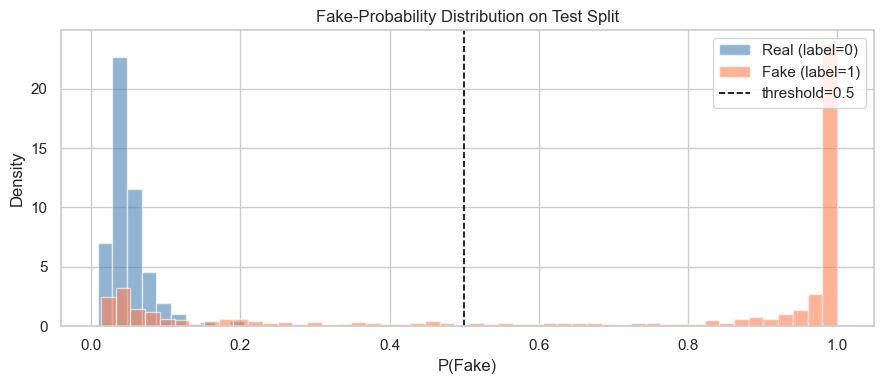

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    all_fake_probs[all_labels == 0],
    bins=50,
    alpha=0.6,
    label="Real (label=0)",
    color="steelblue",
    density=True,
)
ax.hist(
    all_fake_probs[all_labels == 1],
    bins=50,
    alpha=0.6,
    label="Fake (label=1)",
    color="coral",
    density=True,
)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="threshold=0.5")
ax.set_xlabel("P(Fake)")
ax.set_ylabel("Density")
ax.set_title("Fake-Probability Distribution on Test Split")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Attention Weight Distribution


/Users/haila/My File/projects/fake-new-detection/.venv/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/haila/My File/projects/fake-new-detection/.venv/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


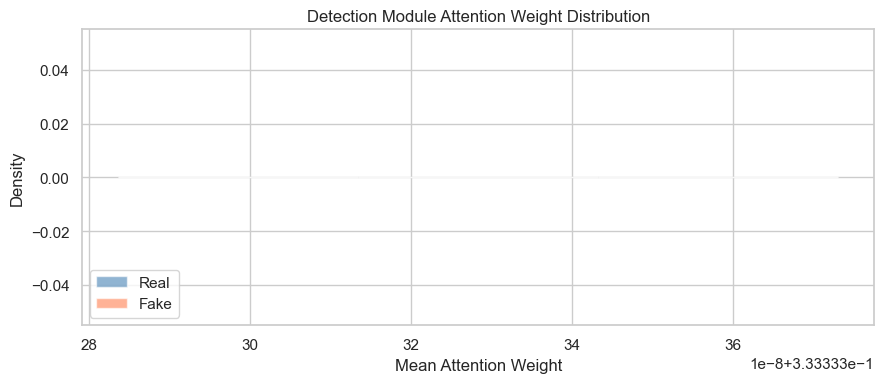

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    all_attn_weights[all_labels == 0],
    bins=50,
    alpha=0.6,
    label="Real",
    color="steelblue",
    density=True,
)
ax.hist(
    all_attn_weights[all_labels == 1],
    bins=50,
    alpha=0.6,
    label="Fake",
    color="coral",
    density=True,
)
ax.set_xlabel("Mean Attention Weight")
ax.set_ylabel("Density")
ax.set_title("Detection Module Attention Weight Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Stage 1 Output Key Shapes (Phase 4 Handoff Verification)


In [21]:
caption, image, _ = next(iter(loaders["test"]))
caption, image = caption.to(DEVICE), image.to(DEVICE)

with torch.no_grad():
    out = model(caption, image)
    det_probs = F.softmax(out["detection_logits"], dim=-1)

stage2_keys = {
    "text_aligned_clip": out["text_aligned_clip"],
    "image_aligned_clip": out["image_aligned_clip"],
    "attention_weights": out["attention_weights"],
    "detection_logits": out["detection_logits"],
    "fake_prob": det_probs[:, 1],
}

print("Stage 1 output shapes (Phase 4 handoff contract):")
rows = []
for k, v in stage2_keys.items():
    print(f"  {k:25s}: {tuple(v.shape)}")
    rows.append({"key": k, "shape": str(tuple(v.shape)), "dtype": str(v.dtype)})

pd.DataFrame(rows)

Stage 1 output shapes (Phase 4 handoff contract):
  text_aligned_clip        : (64, 64)
  image_aligned_clip       : (64, 64)
  attention_weights        : (64, 3)
  detection_logits         : (64, 2)
  fake_prob                : (64,)


,key,shape,dtype
0,text_aligned_clip,"(64, 64)",torch.float32
1,image_aligned_clip,"(64, 64)",torch.float32
2,attention_weights,"(64, 3)",torch.float32
3,detection_logits,"(64, 2)",torch.float32
4,fake_prob,"(64,)",torch.float32


## 9. Single-Pair Inference — Input Your Own Text + Image

Edit `MY_TEXT` and `MY_IMAGE_PATH` below, then run the cell.  
The model will extract PhoBERT token embeddings and ResNet50 image features on-the-fly and predict Real / Fake.


/var/folders/rh/5t55t1152fjbnbkbpyk4_t6c0000gn/T/ipykernel_59071/96009530.py:176: UserWarning: Glyph 7875 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/rh/5t55t1152fjbnbkbpyk4_t6c0000gn/T/ipykernel_59071/96009530.py:176: UserWarning: Glyph 7903 (\N{LATIN SMALL LETTER O WITH HORN AND HOOK ABOVE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/haila/My File/projects/fake-new-detection/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7875 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


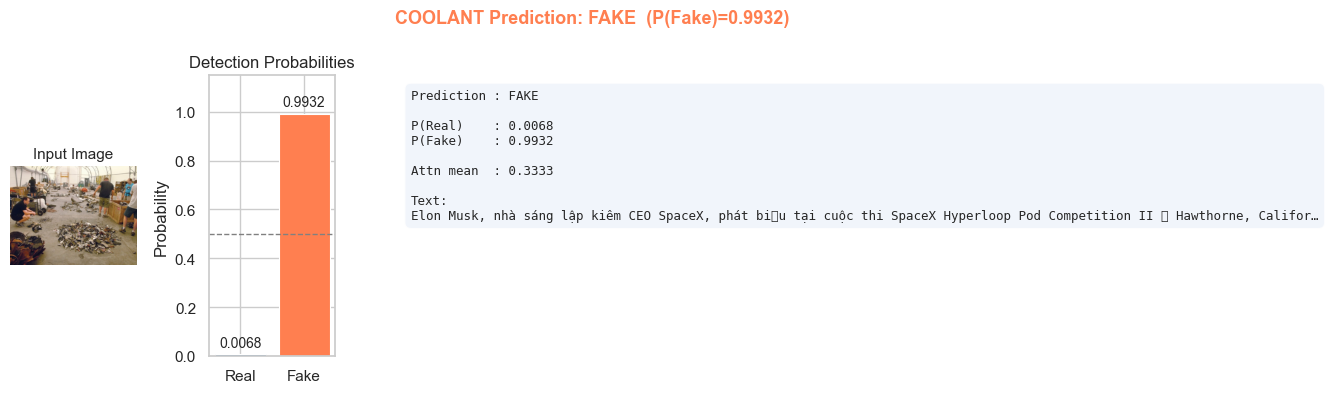


Result: FAKE  —  P(Real)=0.0068  P(Fake)=0.9932


In [30]:
# ── YOUR INPUT ─────────────────────────────────────────────────────────────
# Edit these two values and re-run the cell.
MY_TEXT = "Elon Musk, nhà sáng lập kiêm CEO SpaceX, phát biểu tại cuộc thi SpaceX Hyperloop Pod Competition II ở Hawthorne, California, ngày 27/8/2017. "
MY_IMAGE = "https://i1-vnexpress.vnecdn.net/2026/06/12/Evr9rCgVgAQIibJ-1781246980-8973-1781248176.jpg?w=680&h=0&q=100&dpr=1&fit=crop&s=L225QTLc4cBugips_U7fGg"  # local path  OR  http(s):// URL, e.g.:
#               MY_IMAGE = "/path/to/photo.jpg"
#               MY_IMAGE = "https://example.com/photo.jpg"
#               Leave empty ("") to use a blank (zero) image tensor.
# ───────────────────────────────────────────────────────────────────────────

import io, urllib.request
import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

from transformers import AutoTokenizer, AutoModel
from torchvision import transforms
from PIL import Image

# ── Lazy-load text encoder (PhoBERT) ───────────────────────────────────────
_TEXT_MODEL_HF = "vinai/phobert-base"
_TEXT_SEQ_LEN = config["model"]["text_seq_len"]  # 128
_TEXT_EMBED = config["model"]["text_embed_dim"]  # 768

if "infer_tokenizer" not in dir():
    print(f"Loading {_TEXT_MODEL_HF} tokenizer + model…")
    infer_tokenizer = AutoTokenizer.from_pretrained(_TEXT_MODEL_HF)
    infer_bert = AutoModel.from_pretrained(_TEXT_MODEL_HF).to(DEVICE).eval()
    print("Text encoder ready.")

# ── Lazy-load image encoder (ResNet50) ─────────────────────────────────────
import torchvision.models as tvm

_IMG_DIM = config["model"]["image_dim"]  # 2048

if "infer_resnet" not in dir():
    print("Loading ResNet50…")
    _r50 = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V1)
    infer_resnet = torch.nn.Sequential(*list(_r50.children())[:-1]).to(DEVICE).eval()
    infer_img_transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.CenterCrop((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    print("Image encoder ready.")


# ── Helper: load a PIL image from a local path or a URL ───────────────────
def _load_pil(src: str) -> Image.Image:
    src = src.strip()
    if src.startswith("http://") or src.startswith("https://"):
        print(f"Downloading image from URL…")
        with urllib.request.urlopen(src, timeout=15) as resp:
            return Image.open(io.BytesIO(resp.read())).convert("RGB")
    return Image.open(src).convert("RGB")


# ── Extract text features  →  [1, embed_dim, seq_len] ─────────────────────
with torch.no_grad():
    enc = infer_tokenizer(
        MY_TEXT,
        max_length=_TEXT_SEQ_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    text_feat = infer_bert(**enc).last_hidden_state  # [1, seq_len, 768]
    text_feat = text_feat.permute(0, 2, 1)  # [1, 768, seq_len]

# ── Extract image features  →  [1, 2048] ──────────────────────────────────
with torch.no_grad():
    img_src = MY_IMAGE.strip()
    pil_img = None
    if img_src:
        try:
            pil_img = _load_pil(img_src)
            img_tensor = infer_img_transform(pil_img).unsqueeze(0).to(DEVICE)
            img_feat = infer_resnet(img_tensor).view(1, -1)  # [1, 2048]  — no squeeze!
            has_image = True
        except Exception as e:
            print(f"⚠  Could not load image ({e}) — using zero tensor.")
            img_feat = torch.zeros(1, _IMG_DIM, device=DEVICE)
            has_image = False
    else:
        img_feat = torch.zeros(1, _IMG_DIM, device=DEVICE)
        has_image = False
        print("ℹ  No image given — using zero tensor.")

# ── Model inference (batch-size must be ≥ 2 due to BatchNorm1d in
#    CrossModule4Batch.pooling().squeeze() collapsing the batch dim to 0-D).
#    Workaround: duplicate the single sample, run forward, take index [0]. ──
model.eval()
with torch.no_grad():
    t2 = text_feat.expand(2, -1, -1)  # [2, 768, seq_len]
    i2 = img_feat.expand(2, -1)  # [2, 2048]
    out = model(t2, i2)
    logits = out["detection_logits"][0]  # [2]
    probs = F.softmax(logits, dim=-1)  # [2]
    fake_prob = probs[1].item()
    real_prob = probs[0].item()
    pred_label = "FAKE" if fake_prob >= 0.5 else "REAL"
    attn_mean = out["attention_weights"][0].mean().item()

# ── Display ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 4))

# Left: image thumbnail (or placeholder)
ax_img = fig.add_subplot(1, 3, 1)
if has_image and pil_img is not None:
    ax_img.imshow(np.array(pil_img))
else:
    ax_img.text(
        0.5,
        0.5,
        "No image\n(zero tensor used)",
        ha="center",
        va="center",
        fontsize=11,
        color="gray",
        transform=ax_img.transAxes,
    )
    ax_img.set_facecolor("#f5f5f5")
ax_img.axis("off")
ax_img.set_title("Input Image", fontsize=11)

# Middle: probability bar
ax_bar = fig.add_subplot(1, 3, 2)
bars = ax_bar.bar(
    ["Real", "Fake"],
    [real_prob, fake_prob],
    color=["steelblue", "coral"],
    edgecolor="white",
    linewidth=0.8,
)
ax_bar.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax_bar.set_ylim(0, 1.15)
ax_bar.set_ylabel("Probability")
ax_bar.set_title("Detection Probabilities")
ax_bar.axhline(0.5, color="gray", linestyle="--", linewidth=1)

# Right: text summary
ax_txt = fig.add_subplot(1, 3, 3)
ax_txt.axis("off")
wrap_text = MY_TEXT[:120] + ("…" if len(MY_TEXT) > 120 else "")
summary = (
    f"Prediction : {pred_label}\n\n"
    f"P(Real)    : {real_prob:.4f}\n"
    f"P(Fake)    : {fake_prob:.4f}\n\n"
    f"Attn mean  : {attn_mean:.4f}\n\n"
    f"Text:\n{wrap_text}"
)
ax_txt.text(
    0.02,
    0.95,
    summary,
    va="top",
    ha="left",
    fontsize=9,
    transform=ax_txt.transAxes,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#eef3fb", alpha=0.8),
)

color = "coral" if pred_label == "FAKE" else "steelblue"
plt.suptitle(
    f"COOLANT Prediction: {pred_label}  (P(Fake)={fake_prob:.4f})",
    fontsize=13,
    fontweight="bold",
    color=color,
)
plt.tight_layout()
plt.show()
print(f"\nResult: {pred_label}  —  P(Real)={real_prob:.4f}  P(Fake)={fake_prob:.4f}")